In [2]:
import os, re, glob, math, gc, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Widgets & display
from ipywidgets import (
    IntRangeSlider, IntSlider, Button, Dropdown,
    HBox, VBox, Output, Layout, HTML
)
from IPython.display import display

# Preferred TIFF reader (tifffile → imageio.v3 → PIL fallback)
try:
    from tifffile import imread as TIFF_READ
except Exception:
    try:
        import imageio.v3 as iio
        TIFF_READ = iio.imread
    except Exception:
        from PIL import Image
        def TIFF_READ(p):  # fallback
            return np.array(Image.open(p))

# Matplotlib defaults
plt.rcParams.setdefault("figure.dpi", 100)

100.0

In [ ]:
from setkafluo import (
    move_channels_last, reduce_channels, spectrum_from_cube,
    make_spectrum_image_viewer, plot_channel_ranges_grid,
    make_detectors_viewer, make_weighted_tiff_browser,
    load_npz_cube_channels_last
)

In [4]:
# ---- Globals ----
CH_LO, CH_HI = 100, 1700

IMG_WIDTH_IN       = 6.5
SPEC_WIDTH_IN_BASE = 5.5
SPECTRUM_SCALE     = 1.5
CBAR_WIDTH_IN      = 0.35
MARGIN_W           = 0.8

TILE_WIDTH_IN      = 5.0  # Cell 5 grid tiles

# Data import
In the following cell you will:


1.   Point to DATA_DIR and load sum_spectrum.npz as a 3D cube.
2.   Reorder to (rows, cols, channels) and slice to [CH_LO, CH_HI].
3.   Compute the summed spectrum and display a quick log-scaled preview.

Context. XRF produces spectral images: for each pixel you have a full spectrum, so a 2D scan is actually a 3D dataset (rows × cols × energy channels). A 3D volume would therefore be 4D (x × y × z × channels) and is often called a hypertomogram. In our case we work with a 2D scan, so in the spectrum you’ll see characteristic peaks of different elements.

About formats & tools. At synchrotrons, raw XRF data are typically acquired in HDF5 files or legacy EDF files. Quantitative processing is commonly done via non-linear spectral fitting using software like PyMca ([docs](https://www.silx.org/doc/PyMca/dev/index.html)). For this workshop—because time and objectives are limited—we’ll skip a full fitting pipeline and directly explore the raw data and processed images.

As (rows, cols, channels): (762, 341, 2048)
Reduced (rows, cols, channels): (762, 341, 1601)
Reduced spectrum shape: (1601,)


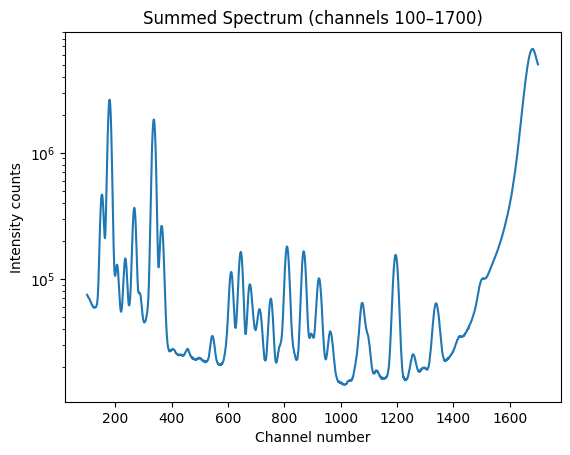

In [ ]:
# Paths
DATA_DIR = Path("") # set your data directory here
NPZ_PATH = DATA_DIR / "sum_spectrum.npz"

# Load cube as (rows, cols, channels)
data = load_npz_cube_channels_last(NPZ_PATH)
print("As (rows, cols, channels):", data.shape)

# Reduce channels
arr_red, channel_numbers = reduce_channels(data, CH_LO, CH_HI)
print("Reduced (rows, cols, channels):", arr_red.shape)

# Summed spectrum
spectrum_red = spectrum_from_cube(arr_red)
print("Reduced spectrum shape:", spectrum_red.shape)

# Plot spectrum (log-y)
with plt.ioff():
    fig, ax = plt.subplots()
    ax.plot(channel_numbers, spectrum_red)
    ax.set_yscale("log")
    ax.set_xlabel("Channel number")
    ax.set_ylabel("Intensity counts")
    ax.set_title(f"Summed Spectrum (channels {CH_LO}–{CH_HI})")
    display(fig)
    plt.close(fig)

# Interactive spectrum ↔ image explorer

In the following cell you will:
1.   Interactively choose a channel range using the Channels slider.
2.   Drag the center of that range with the Center slider while keeping the same width.
3.   See the spectrum with the selected band highlighted, and the corresponding summed image on the right.
4.   Observe how spectral features map to spatial structure (geometry preserved; log view for contrast).

5.   Note down the ranges with interesting distributions, you will need them in the following step

Tip: Narrow ranges around peaks to localize elemental distributions.

In [6]:
ui = make_spectrum_image_viewer(
    arr=arr_red,
    spectrum=spectrum_red,
    chan_vals=channel_numbers,
    ch_lo=CH_LO, ch_hi=CH_HI,
    img_width_in=IMG_WIDTH_IN,
    spec_width_in_base=SPEC_WIDTH_IN_BASE,
    spectrum_scale=SPECTRUM_SCALE,
    cbar_width_in=CBAR_WIDTH_IN,
    margin_w=MARGIN_W
)
display(ui)

# Batch visualization of selected channel ranges

In the following cell you will:
1.   Define a list of channel windows (RANGES) you care about.
2.   Render a grid of images, one per range, each with its own colorbar and optional log1p transform.
3.   Optionally switch to percentile scaling to tame outliers and enhance contrast.

How to use: Add/remove (lo, hi) pairs in RANGES. Use this when you want a quick side-by-side comparison of several spectral bands.

In [ ]:
# Define ranges (actual channel numbers, inclusive)
# add more like (800, 850), (1200, 1300),
RANGES = [

]

plot_channel_ranges_grid(
    arr=arr_red,
    ranges=RANGES,
    ch_bounds=(CH_LO, CH_HI),
    n_cols=2,
    tile_width_in=TILE_WIDTH_IN,
    use_log1p=False,          # True if you prefer log view
    scale_mode="full",        # or "percentile"
    p_lo=2.0, p_hi=98.0
)

# Detector-element explorer (sum vs. individual detectors)

In the following cell you will:
1.   Load the sum_spectrum cube and all detector_element_*.npz cubes.
2.   Precompute the summed images for each range once (fast browsing thereafter).
3.   Browse ranges with a slider and flip detectors with Prev/Next buttons.
4.   Compare detectors on a shared color scale per range for fair visual comparison.

Goal: Check elements of the detectors and compare their noise quality and how it differs from summed image.

In [ ]:
viewer = make_detectors_viewer(
    data_dir=DATA_DIR,
    ranges=RANGES,
    use_log1p=True,
    img_width_in=7.0
)
display(viewer)

# Weighted TIFF browser (elemental area densities)

In the following cell you will:
1.   Scan WEIGHTS_DIR for files matching IMG_weighted_*_area_density_ngmm2.tif[f].
2.   Load all 2D maps and compute per-image full-range color limits (no shared normalization).
3.   Browse the maps quickly via a dropdown or Prev/Next buttons.

Context. These maps are the fitted and identified elemental distributions produced by tools such as PyMca (non-linear spectral fitting). Unlike raw channel sums, these images are quantitative—each pixel reports an areal density (typically in ng/mm², as indicated in the filename). This means values are physically meaningful and comparable within the same dataset and processing configuration.

Tip. If some elements span a large dynamic range, you can enable a log view in the code cell to reveal low-intensity structure while still preserving bright features.

In [ ]:
# set path to weighted sums directory
WEIGHTS_DIR = Path("")
PATTERNS = [
    "IMG_weighted_*_area_density_ngmm2.tif",
    "IMG_weighted_*_area_density_ngmm2.tiff",
]

tiff_browser = make_weighted_tiff_browser(
    weights_dir=WEIGHTS_DIR,
    patterns=PATTERNS,
    use_log1p=False,   # set True if you want log1p
    img_width_in=7.0
)
display(tiff_browser)